In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
sys.path.append("/home/zz1994/packages/ABCMB/ABCMB")

In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
from jax.scipy.special import gamma, factorial
import scipy
from scipy.special import spherical_jn
from scipy.optimize import brentq
import equinox as eqx
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time

from ABCMB import main, background, perturbations, spectrum
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

ERROR:2026-01-26 15:56:09,407:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:34: operation cudaRuntimeGetVersion(&version) failed: Error loading CUDA libraries. GPU will not be used.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zz1994/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 229

# Settings

In [5]:
xsize = 5000 # Number of x points to save for each jl
xmin_target = 1.e-10 # x value corresponding to this target value of jl
ls = spectrum.l_tab

In [6]:
path = "/home/zz1994/packages/ABCMB/ABCMB/new_bessel_tab" # Output directory

# Helper functions

In [7]:
def first_x(func, target=xmin_target, x_min=1e-8, x_max_init=None, growth=1.5, max_iter=200):
    """
    Find the first x > 0 such that spherical_jn(l, x) = target.

    Parameters
    ----------
    l : int
        Order of the spherical Bessel function j_l(x).
    target : float, optional
        Target value for j_l(x). Default is 1e-5.
    x_min : float, optional
        Small positive starting x to avoid the origin. Default is 1e-8.
    x_max_init : float or None, optional
        Initial guess for the upper bracket. If None, uses max(10, l).
    growth : float, optional
        Multiplicative factor to grow the upper bracket if needed.
    max_iter : int, optional
        Maximum number of bracket expansion steps.

    Returns
    -------
    x_root : float
        The first x where spherical_jn(l, x) = target.

    Raises
    ------
    RuntimeError
        If a valid bracket cannot be found.
    """

    def f(x):
        return func(x) - target

    # Initial bracket
    x_lo = x_min
    f_lo = f(x_lo)

    if x_max_init is None:
        x_hi = max(10.0, float(l))
    else:
        x_hi = float(x_max_init)

    f_hi = f(x_hi)

    # Expand upper bracket until sign change or max_iter reached
    it = 0
    while f_lo * f_hi > 0 and it < max_iter:
        x_hi *= growth
        f_hi = f(x_hi)
        it += 1

    if f_lo * f_hi > 0:
        raise RuntimeError(
            f"Failed to bracket a root for l={l}. "
            f"Last bracket: x_lo={x_lo}, x_hi={x_hi}, "
            f"f_lo={f_lo:.3e}, f_hi={f_hi:.3e}"
        )

    # Root find inside bracket
    x_root = brentq(f, x_lo, x_hi)
    return x_root

In [10]:
def kth_local_maximum(
    f,
    fp,
    k=5,
    *,
    x0=0.0,
    step=0.1,
    step_max=np.pi,
    step_growth=1.05,
    bracket_expand=1.5,
    max_iter=200000,
    root_xtol=1e-12,
    root_rtol=1e-10,
):
    """
    Find the x-location of the k-th local maximum of f(x) for x >= x0.

    Requirements:
      - fp(x) is the analytic first derivative of f(x)
      - f is reasonably smooth; maxima satisfy fp(x)=0 with sign change + -> -

    Method:
      - March forward from x0, looking for sign changes of fp.
      - On each sign change, use brentq to find the root of fp.
      - Classify as a local maximum if fp crosses + to -.

    Parameters
    ----------
    f : callable
        Function f(x). (Not strictly required for finding maxima, but useful to keep.)
    fp : callable
        First derivative f'(x).
    k : int
        Which local maximum to find (1 = first maximum, 5 = fifth maximum).
    x0 : float
        Search starts at x0 and proceeds to the right.
    step : float
        Initial marching step size.
    step_max : float
        Maximum allowed step size during marching.
    step_growth : float
        Factor used to gently increase step after successful non-root intervals.
    bracket_expand : float
        If fp doesn't change sign, how aggressively to expand the interval.
        (Used indirectly by step growth; kept here for easy tuning.)
    max_iter : int
        Safety cap on marching iterations.
    root_xtol, root_rtol : float
        Tolerances passed to brentq.

    Returns
    -------
    x_peak : float
        Location of the k-th local maximum.
    """
    if k < 1:
        raise ValueError("k must be >= 1")
    if step <= 0:
        raise ValueError("step must be > 0")

    # Helper: classify a root r as max if fp changes + -> - across r
    def is_maximum(r):
        # Small probe scale relative to location (avoid 0)
        eps = 1e-7 * max(1.0, abs(r))
        left = fp(r - eps)
        right = fp(r + eps)
        return (left > 0) and (right < 0)

    x = float(x0)
    f_prev = fp(x)

    # If we start exactly at a critical point, nudge right
    if f_prev == 0.0:
        x += 1e-6
        f_prev = fp(x)

    found = 0
    it = 0

    # March forward and find successive roots of fp
    while found < k:
        it += 1
        if it > max_iter:
            raise RuntimeError("Exceeded max_iter while searching for maxima. "
                               "Try increasing max_iter, step, or providing a better x0.")

        x_next = x + step
        f_next = fp(x_next)

        # Case 1: sign change brackets a root
        if f_prev * f_next < 0:
            r = brentq(fp, x, x_next, xtol=root_xtol, rtol=root_rtol, maxiter=200)

            if is_maximum(r):
                found += 1
                if found == k:
                    return r

            # Move just right of the root to avoid re-detecting it
            x = r + 1e-6 * max(1.0, abs(r))
            f_prev = fp(x)

            # After a root, a moderate step is usually safe
            step = min(step_max, max(step, 0.5 * step))

        else:
            # No bracketed root; advance
            x, f_prev = x_next, f_next
            # Slowly increase step so we don't crawl forever
            step = min(step_max, step * step_growth)

    raise RuntimeError("Unexpected fallthrough.")

# Approximation functions

In [11]:
Q = lambda l, x : jnp.sqrt(x**2-l**2) - l*jnp.pi/2 + l * jnp.arcsin(l/x)
J = lambda l, x : jnp.sqrt(2/jnp.pi/jnp.sqrt(x**2-l**2)) * jnp.cos(Q(l, x) - jnp.pi/4)
j = lambda l, x : jnp.sqrt(jnp.pi/2/x) * J(l+1/2, x)

/state/partition1/job-4589665/ipykernel_642010/2279223858.py:4: RuntimeWarning: invalid value encountered in scalar divide
  df = lambda x : ( (3*(l-2)*(l-1)*l - 2*(l-3)*x**2) * spherical_jn(l, x) + x * (-3*(6 + l + l**2) + 2*x**2) * spherical_jn(l + 1, x) ) / (2 * x**3)


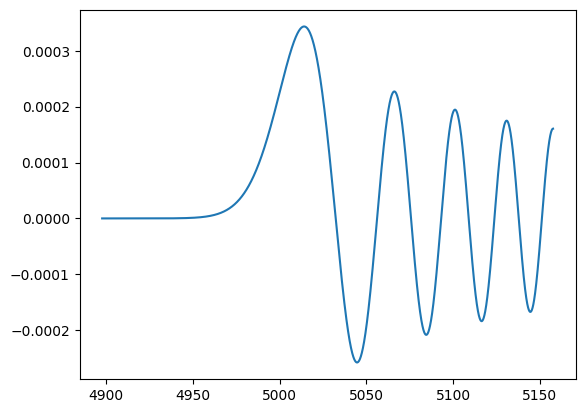

0.052026077798473125


In [13]:
l=5000
f = lambda x : 0.5 * ( 3 * ( ((l-1)*l - x**2) * spherical_jn(l, x) + 2*x * spherical_jn(l+1, x) ) / x**2 + spherical_jn(l, x) )
approxf = lambda x : 0.5 * ( 3 * ( ((l-1)*l - x**2) * j(l, x) + 2*x * j(l+1, x) ) / x**2 + j(l, x) )
df = lambda x : ( (3*(l-2)*(l-1)*l - 2*(l-3)*x**2) * spherical_jn(l, x) + x * (-3*(6 + l + l**2) + 2*x**2) * spherical_jn(l + 1, x) ) / (2 * x**3)
xs = jnp.linspace(first_x(f), kth_local_maximum(f, df), xsize)
plt.plot(xs, f(xs))
#plt.plot(xs, abs(spherical_jn(l, xs)))
#plt.yscale("log")
#plt.xlim((4010, 4200))
plt.show()
print(xs[1]-xs[0])

/state/partition1/job-4589665/ipykernel_642010/2279223858.py:4: RuntimeWarning: invalid value encountered in scalar divide
  df = lambda x : ( (3*(l-2)*(l-1)*l - 2*(l-3)*x**2) * spherical_jn(l, x) + x * (-3*(6 + l + l**2) + 2*x**2) * spherical_jn(l + 1, x) ) / (2 * x**3)


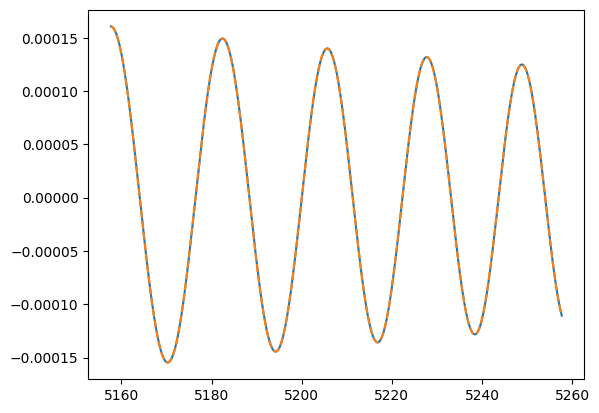

In [14]:
xs = np.linspace(kth_local_maximum(f, df), kth_local_maximum(f, df)+100, xsize)
plt.plot(xs, f(xs))
plt.plot(xs, approxf(xs), "--")
plt.show()

# Saving

## $\phi_0$

In [38]:
x_res = np.zeros((xsize, spectrum.l_tab.size))
jl_res = np.zeros((xsize, spectrum.l_tab.size))
for i in range(spectrum.l_tab.size):
    l = spectrum.l_tab[i]
    f = lambda x : spherical_jn(l, x)
    df = lambda x : spherical_jn(l, x, derivative=True)
    xmin = first_x(f)
    xmax = kth_local_maximum(f, df)
    if l <= 20:
        xs = jnp.linspace(0, xmax, xsize)
    else:
        xs = jnp.linspace(xmin, xmax, xsize)
    x_res[:, i] = xs
    jl_res[:, i] = f(xs)

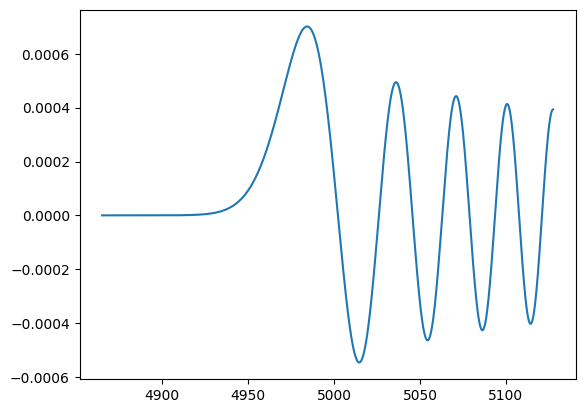

In [39]:
plt.plot(x_res[:, 159], jl_res[:, 159])
plt.show()

In [40]:
np.savetxt(path+"/xphi0.txt", x_res, fmt='%.10e')
np.savetxt(path+"/phi0.txt", jl_res, fmt='%.10e')

## $\phi_1$

In [41]:
x_res = np.zeros((xsize, spectrum.l_tab.size))
phi1_res = np.zeros((xsize, spectrum.l_tab.size))
for i in range(spectrum.l_tab.size):
    l = spectrum.l_tab[i]
    f = lambda x : spherical_jn(l, x, derivative=True)
    df = lambda x : ((l**2-l-x**2)*spherical_jn(l, x) + 2*x*spherical_jn(l+1, x))/x**2
    xmin = first_x(f)
    xmax = kth_local_maximum(f, df)
    if l <= 20:
        xs = jnp.linspace(0, xmax, xsize)
    else:
        xs = jnp.linspace(xmin, xmax, xsize)
    x_res[:, i] = xs
    phi1_res[:, i] = f(xs)

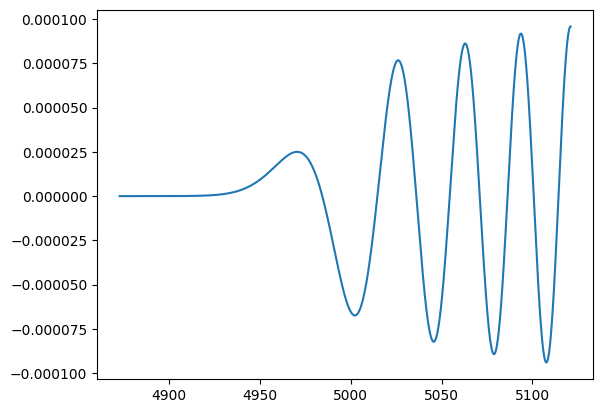

In [42]:
plt.plot(x_res[:, 159], phi1_res[:, 159])
plt.show()

In [43]:
np.savetxt(path+"/xphi1.txt", x_res, fmt='%.10e')
np.savetxt(path+"/phi1.txt", phi1_res, fmt='%.10e')

## $\phi_2$

In [44]:
x_res = np.zeros((xsize, spectrum.l_tab.size))
phi2_res = np.zeros((xsize, spectrum.l_tab.size))

# Here the l=2 is special since at x=0 the function phi2(l=2, x=0) = 1/5 != 0, and needs to be treated separately.
l=2
f = lambda x : jnp.where(
    x == 0,
    1./5.,
    0.5 * ( 3 * ( ((l-1)*l - x**2) * spherical_jn(l, x) + 2*x * spherical_jn(l+1, x) ) / x**2 + spherical_jn(l, x) ) 
)
df = lambda x : ( (3*(l-2)*(l-1)*l - 2*(l-3)*x**2) * spherical_jn(l, x) + x * (-3*(6 + l + l**2) + 2*x**2) * spherical_jn(l + 1, x) ) / (2 * x**3)
xmin = first_x(f)
xmax = kth_local_maximum(f, df)
xs = jnp.linspace(0, xmax, xsize)
x_res[:, 0] = xs
phi2_res[:, 0] = f(xs)

for i in range(1, spectrum.l_tab.size):
    l = spectrum.l_tab[i]
    f = lambda x : jnp.where(
        x == 0,
        0.,
        0.5 * ( 3 * ( ((l-1)*l - x**2) * spherical_jn(l, x) + 2*x * spherical_jn(l+1, x) ) / x**2 + spherical_jn(l, x) )    
    )       
    df = lambda x : ( (3*(l-2)*(l-1)*l - 2*(l-3)*x**2) * spherical_jn(l, x) + x * (-3*(6 + l + l**2) + 2*x**2) * spherical_jn(l + 1, x) ) / (2 * x**3)
    xmin = first_x(f)
    xmax = kth_local_maximum(f, df)
    if l <= 20:
        xs = jnp.linspace(0, xmax, xsize)
    else:
        xs = jnp.linspace(xmin, xmax, xsize)
    x_res[:, i] = xs
    phi2_res[:, i] = f(xs)

/state/partition1/job-4589665/ipykernel_642010/3346058381.py:11: RuntimeWarning: invalid value encountered in scalar divide
  df = lambda x : ( (3*(l-2)*(l-1)*l - 2*(l-3)*x**2) * spherical_jn(l, x) + x * (-3*(6 + l + l**2) + 2*x**2) * spherical_jn(l + 1, x) ) / (2 * x**3)


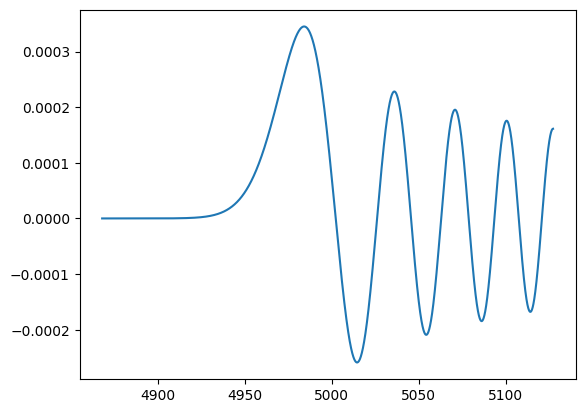

In [45]:
plt.plot(x_res[:, 159], phi2_res[:, 159])
plt.show()

In [47]:
#np.savetxt(path+"/xphi2.txt", x_res, fmt='%.10e')
#np.savetxt(path+"/phi2.txt", phi2_res, fmt='%.10e')

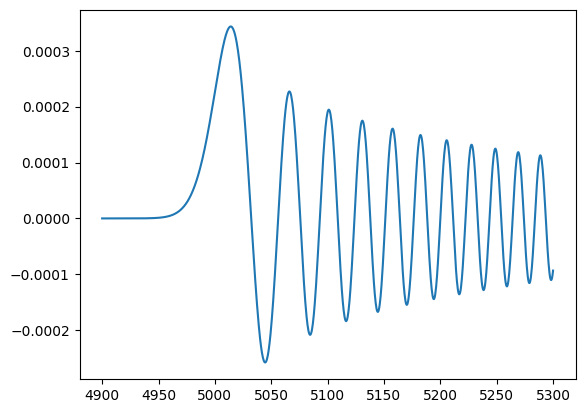

In [13]:
x = jnp.linspace(4900, 5300, 1000)
plt.plot(x, spectrum.phi2(160, x))
plt.show()

In [58]:
spectrum.l_tab[160]

Array(5000, dtype=int64)